In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Set $WORK environment variable if running on Jean Zay
WORK = os.environ.get('WORK', os.path.expanduser('~/JeanZay'))
print(f"Working directory: {WORK}")

Working directory: /lustre/fswork/projects/rech/dtn/uap38od


## 1. Load Datasets

In [2]:
# BRSET dataset
brset_path = Path(WORK) / 'datasets' / 'BRSET' / 'brset'
brset_df = pd.read_csv(brset_path / 'labels_brset.csv')
brset_images_path = brset_path / 'images_224'

# mBRSET dataset
mbrset_path = Path(WORK) / 'datasets' / 'mBRSET' / 'mbrset'
mbrset_df = pd.read_csv(mbrset_path / 'labels_mbrset.csv')
mbrset_images_path = mbrset_path / 'images_224'

print(f"BRSET shape: {brset_df.shape}")
print(f"mBRSET shape: {mbrset_df.shape}")

BRSET shape: (16266, 34)
mBRSET shape: (5164, 24)


## 2. BRSET Dataset Analysis

In [3]:
# Basic info
print("=== BRSET Dataset ===")
print(f"Total images: {len(brset_df)}")
print(f"\nColumns: {list(brset_df.columns)}")
print(f"\nFirst few rows:")
brset_df.head()

=== BRSET Dataset ===
Total images: 16266

Columns: ['image_id', 'patient_id', 'camera', 'patient_age', 'comorbidities', 'diabetes_time_y', 'insuline', 'patient_sex', 'exam_eye', 'diabetes', 'nationality', 'optic_disc', 'vessels', 'macula', 'DR_SDRG', 'DR_ICDR', 'focus', 'iluminaton', 'image_field', 'artifacts', 'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'other', 'quality']

First few rows:


,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality
0,img00001,1,Canon CR,48.0,diabetes1,12,yes,1,1,yes,...,0,0,0,0,0,0,0,1,0,Adequate
1,img00002,1,Canon CR,48.0,diabetes1,12,yes,1,2,yes,...,0,0,0,0,0,0,0,1,0,Adequate
2,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
3,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
4,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate


In [4]:
# Missing values
print("Missing values per column:")
missing = brset_df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Missing values per column:


insuline           14552
diabetes_time_y    14356
comorbidities       8236
patient_age         5445
dtype: int64

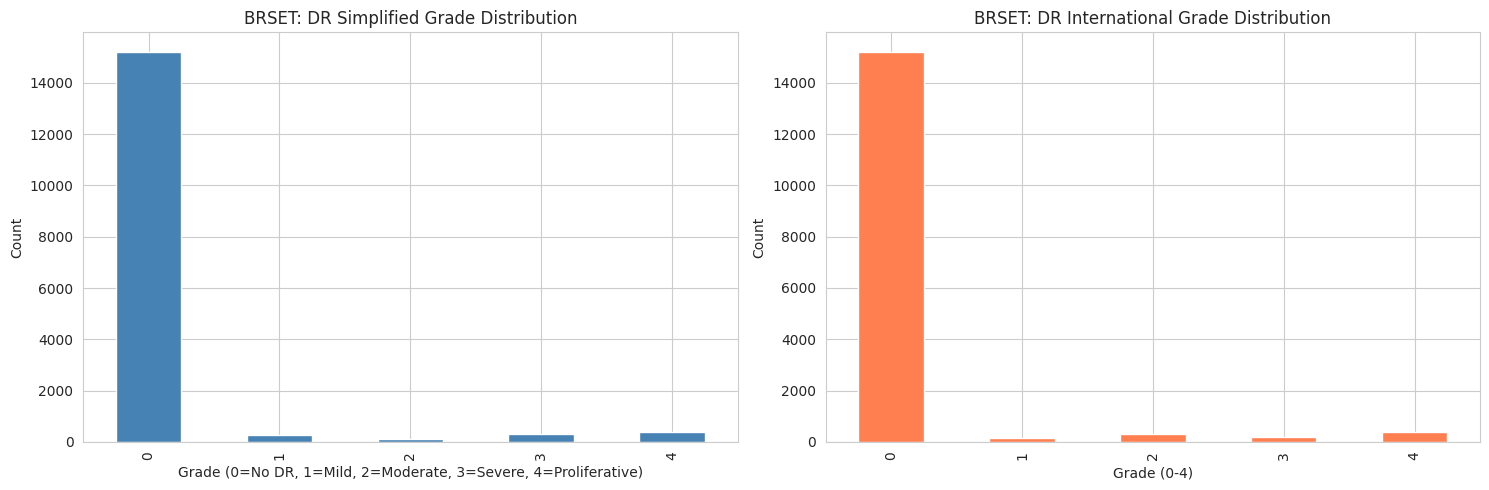


DR_SDRG distribution:
DR_SDRG
0    15212
1      254
2      108
3      296
4      396
Name: count, dtype: int64

DR_ICDR distribution:
DR_ICDR
0    15210
1      162
2      310
3      190
4      394
Name: count, dtype: int64


In [5]:
# Diabetic Retinopathy severity distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# DR_SDRG (Simplified DR Grade)
brset_df['DR_SDRG'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('BRSET: DR Simplified Grade Distribution')
axes[0].set_xlabel('Grade (0=No DR, 1=Mild, 2=Moderate, 3=Severe, 4=Proliferative)')
axes[0].set_ylabel('Count')

# DR_ICDR (International DR Grade)
brset_df['DR_ICDR'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('BRSET: DR International Grade Distribution')
axes[1].set_xlabel('Grade (0-4)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\nDR_SDRG distribution:")
print(brset_df['DR_SDRG'].value_counts().sort_index())
print(f"\nDR_ICDR distribution:")
print(brset_df['DR_ICDR'].value_counts().sort_index())

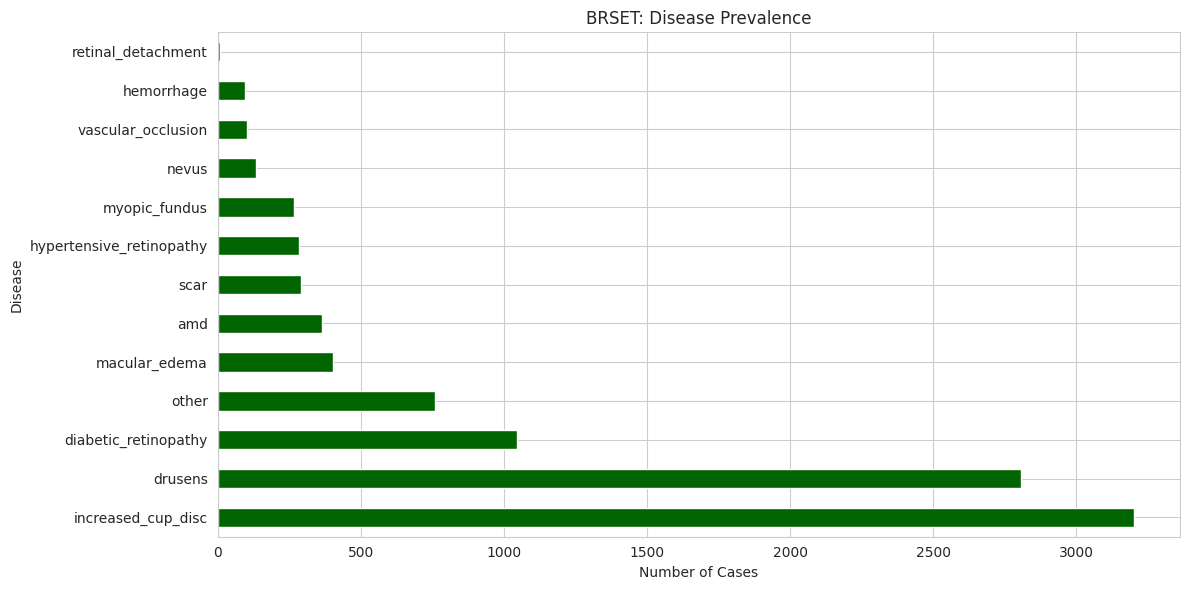


Disease prevalence:
increased_cup_disc          3202
drusens                     2807
diabetic_retinopathy        1046
other                        758
macular_edema                402
amd                          366
scar                         290
hypertensive_retinopathy     283
myopic_fundus                268
nevus                        134
vascular_occlusion           103
hemorrhage                    96
retinal_detachment             7
dtype: int64


In [6]:
# Disease prevalence
disease_cols = ['diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd', 
                'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 
                'hemorrhage', 'retinal_detachment', 'myopic_fundus', 
                'increased_cup_disc', 'other']

disease_prevalence = brset_df[disease_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
disease_prevalence.plot(kind='barh', color='darkgreen')
plt.title('BRSET: Disease Prevalence')
plt.xlabel('Number of Cases')
plt.ylabel('Disease')
plt.tight_layout()
plt.show()

print("\nDisease prevalence:")
print(disease_prevalence)

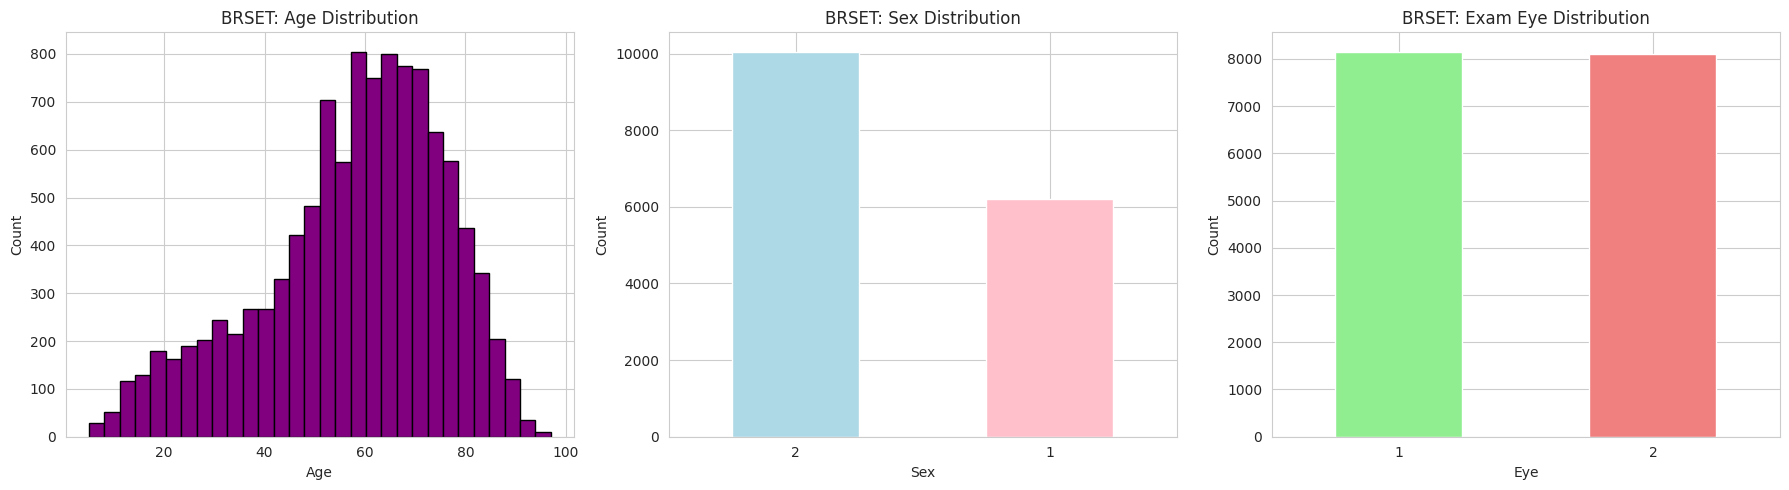


Age statistics:
count    10821.000000
mean        57.655947
std         18.260156
min          5.000000
25%         47.000000
50%         61.000000
75%         71.000000
max         97.000000
Name: patient_age, dtype: float64


In [7]:
# Patient demographics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
brset_df['patient_age'].hist(bins=30, ax=axes[0], color='purple', edgecolor='black')
axes[0].set_title('BRSET: Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Sex distribution
brset_df['patient_sex'].value_counts().plot(kind='bar', ax=axes[1], color=['lightblue', 'pink'])
axes[1].set_title('BRSET: Sex Distribution')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Exam eye
brset_df['exam_eye'].value_counts().plot(kind='bar', ax=axes[2], color=['lightgreen', 'lightcoral'])
axes[2].set_title('BRSET: Exam Eye Distribution')
axes[2].set_xlabel('Eye')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print(f"\nAge statistics:")
print(brset_df['patient_age'].describe())

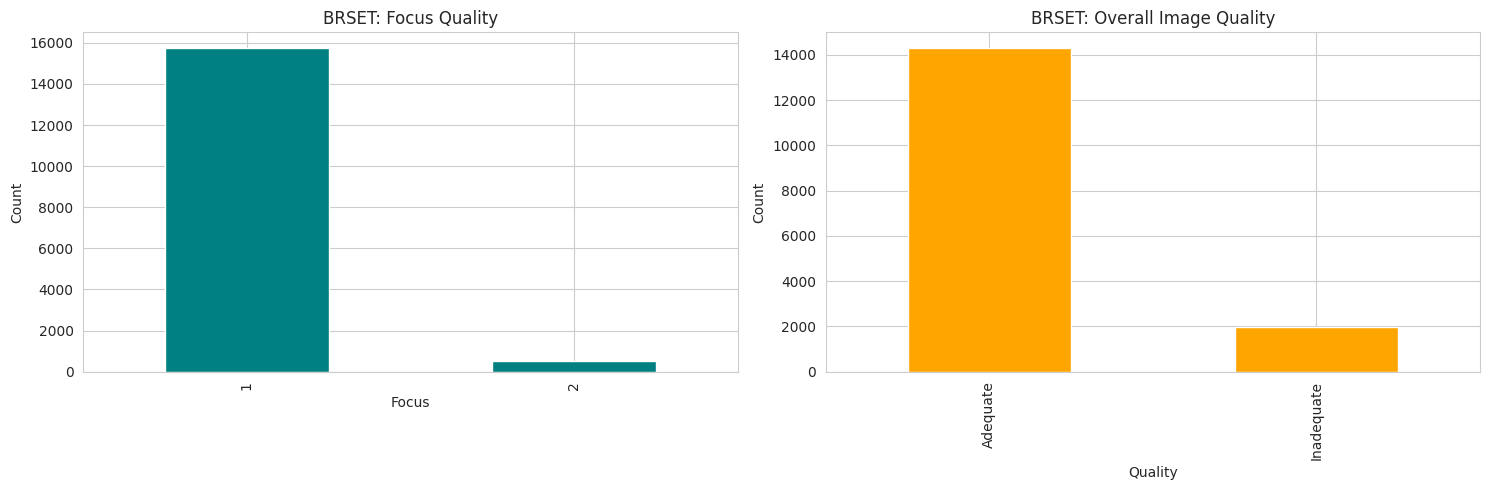


Quality distribution:
quality
Adequate      14279
Inadequate     1987
Name: count, dtype: int64


In [8]:
# Image quality metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Focus quality
brset_df['focus'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('BRSET: Focus Quality')
axes[0].set_xlabel('Focus')
axes[0].set_ylabel('Count')

# Overall quality
brset_df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('BRSET: Overall Image Quality')
axes[1].set_xlabel('Quality')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\nQuality distribution:")
print(brset_df['quality'].value_counts().sort_index())

## 3. mBRSET Dataset Analysis

In [9]:
# Basic info
print("=== mBRSET Dataset ===")
print(f"Total images: {len(mbrset_df)}")
print(f"Unique patients: {mbrset_df['patient'].nunique()}")
print(f"Images per patient: {len(mbrset_df) / mbrset_df['patient'].nunique():.1f}")
print(f"\nColumns: {list(mbrset_df.columns)}")
print(f"\nFirst few rows:")
mbrset_df.head()

=== mBRSET Dataset ===
Total images: 5164
Unique patients: 1291
Images per patient: 4.0

Columns: ['patient', 'age', 'sex', 'dm_time', 'insulin', 'insulin_time', 'oraltreatment_dm', 'systemic_hypertension', 'insurance', 'educational_level', 'alcohol_consumption', 'smoking', 'obesity', 'vascular_disease', 'acute_myocardial_infarction', 'nephropathy', 'neuropathy', 'diabetic_foot', 'file', 'laterality', 'final_artifacts', 'final_quality', 'final_icdr', 'final_edema']

First few rows:


,patient,age,sex,dm_time,insulin,insulin_time,oraltreatment_dm,systemic_hypertension,insurance,educational_level,...,acute_myocardial_infarction,nephropathy,neuropathy,diabetic_foot,file,laterality,final_artifacts,final_quality,final_icdr,final_edema
0,1,58,1,15.0,1.0,NaN,1.0,1.0,0.0,3.0,...,1.0,1.0,0.0,0.0,1.1.jpg,right,yes,yes,4.0,no
1,1,58,1,15.0,1.0,NaN,1.0,1.0,0.0,3.0,...,1.0,1.0,0.0,0.0,1.2.jpg,right,yes,yes,4.0,no
2,1,58,1,15.0,1.0,NaN,1.0,1.0,0.0,3.0,...,1.0,1.0,0.0,0.0,1.3.jpg,left,yes,yes,4.0,no
3,1,58,1,15.0,1.0,NaN,1.0,1.0,0.0,3.0,...,1.0,1.0,0.0,0.0,1.4.jpg,left,yes,yes,4.0,no
4,10,63,0,7.0,0.0,NaN,1.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,10.1.jpg,right,yes,yes,0.0,no


In [10]:
# Missing values
print("Missing values per column:")
missing = mbrset_df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Missing values per column:


insulin_time                   4148
final_icdr                      280
final_edema                     265
diabetic_foot                   108
smoking                          88
acute_myocardial_infarction      84
nephropathy                      80
obesity                          76
alcohol_consumption              76
neuropathy                       76
vascular_disease                 76
dm_time                          56
educational_level                52
insurance                        48
insulin                          48
oraltreatment_dm                 44
systemic_hypertension            44
dtype: int64

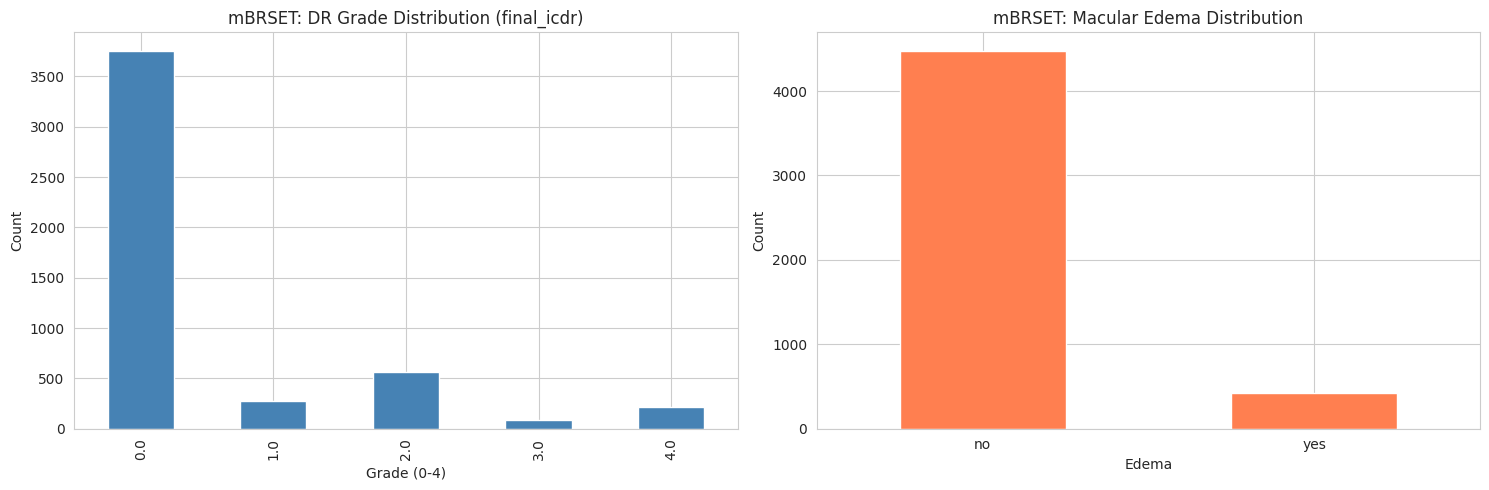


final_icdr distribution:
final_icdr
0.0    3750
1.0     272
2.0     568
3.0      82
4.0     212
Name: count, dtype: int64

final_edema distribution:
final_edema
no     4472
yes     427
Name: count, dtype: int64


In [11]:
# DR severity and edema distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# final_icdr (DR grade)
mbrset_df['final_icdr'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('mBRSET: DR Grade Distribution (final_icdr)')
axes[0].set_xlabel('Grade (0-4)')
axes[0].set_ylabel('Count')

# final_edema
mbrset_df['final_edema'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('mBRSET: Macular Edema Distribution')
axes[1].set_xlabel('Edema')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print(f"\nfinal_icdr distribution:")
print(mbrset_df['final_icdr'].value_counts().sort_index())
print(f"\nfinal_edema distribution:")
print(mbrset_df['final_edema'].value_counts())

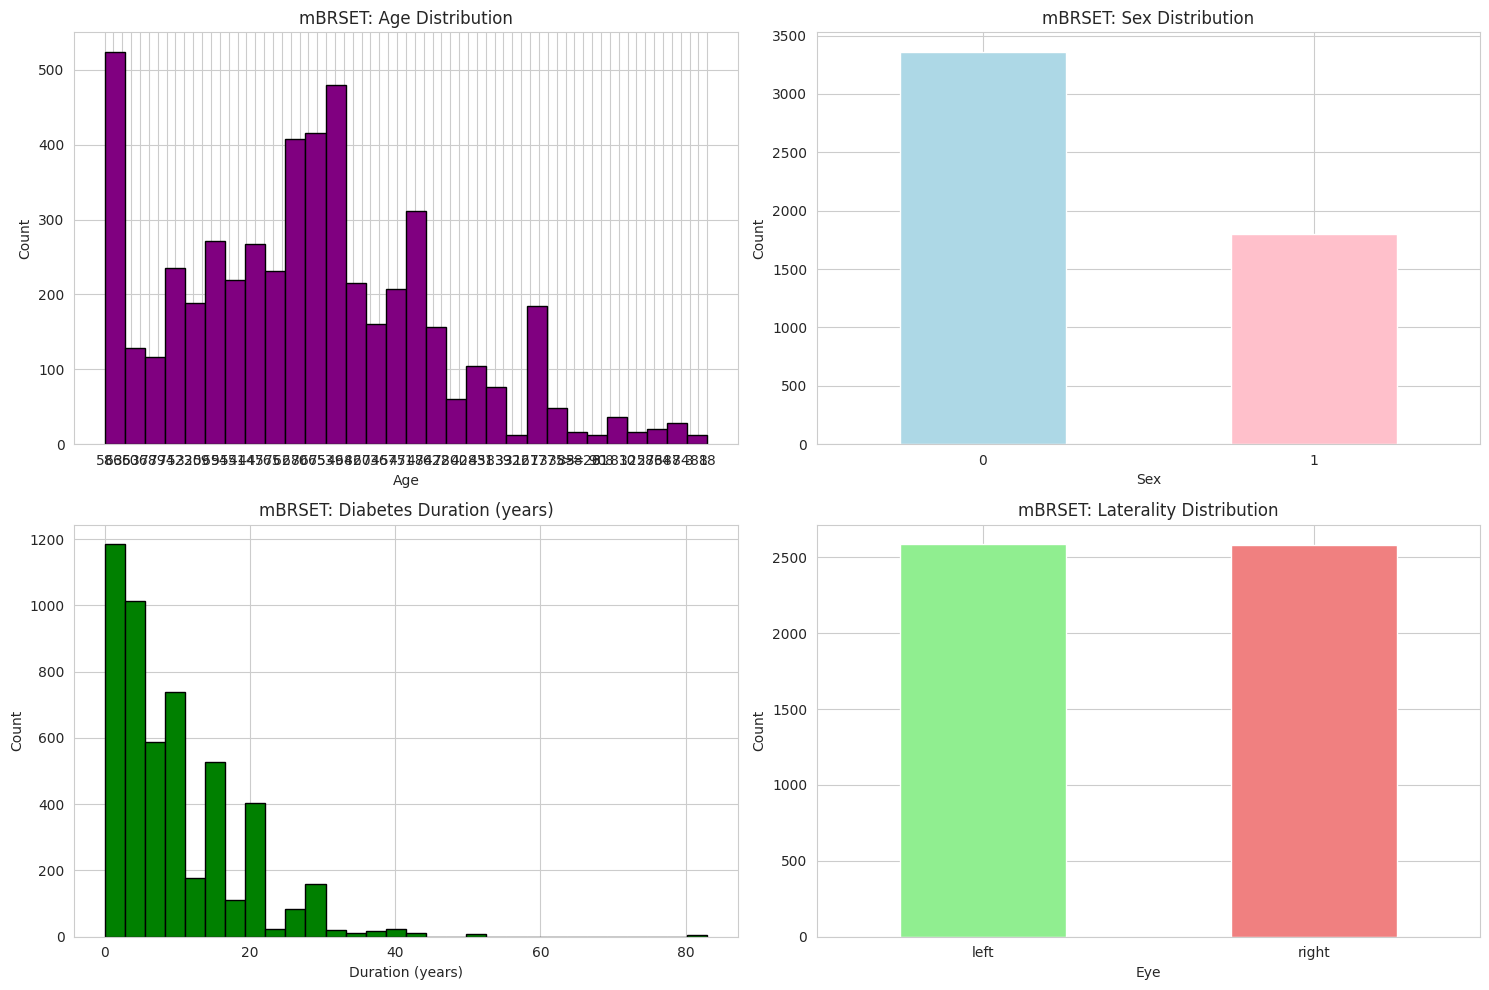


Age statistics:
count     5164
unique      69
top         64
freq       260
Name: age, dtype: object

Diabetes duration statistics:
count    5108.000000
mean        9.541112
std         8.639284
min         0.000000
25%         3.000000
50%         7.000000
75%        15.000000
max        83.000000
Name: dm_time, dtype: float64


In [12]:
# Patient demographics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age distribution
mbrset_df['age'].hist(bins=30, ax=axes[0,0], color='purple', edgecolor='black')
axes[0,0].set_title('mBRSET: Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# Sex distribution
mbrset_df['sex'].value_counts().plot(kind='bar', ax=axes[0,1], color=['lightblue', 'pink'])
axes[0,1].set_title('mBRSET: Sex Distribution')
axes[0,1].set_xlabel('Sex')
axes[0,1].set_ylabel('Count')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)

# Diabetes duration
mbrset_df['dm_time'].hist(bins=30, ax=axes[1,0], color='green', edgecolor='black')
axes[1,0].set_title('mBRSET: Diabetes Duration (years)')
axes[1,0].set_xlabel('Duration (years)')
axes[1,0].set_ylabel('Count')

# Laterality
mbrset_df['laterality'].value_counts().plot(kind='bar', ax=axes[1,1], color=['lightgreen', 'lightcoral'])
axes[1,1].set_title('mBRSET: Laterality Distribution')
axes[1,1].set_xlabel('Eye')
axes[1,1].set_ylabel('Count')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print(f"\nAge statistics:")
print(mbrset_df['age'].describe())
print(f"\nDiabetes duration statistics:")
print(mbrset_df['dm_time'].describe())

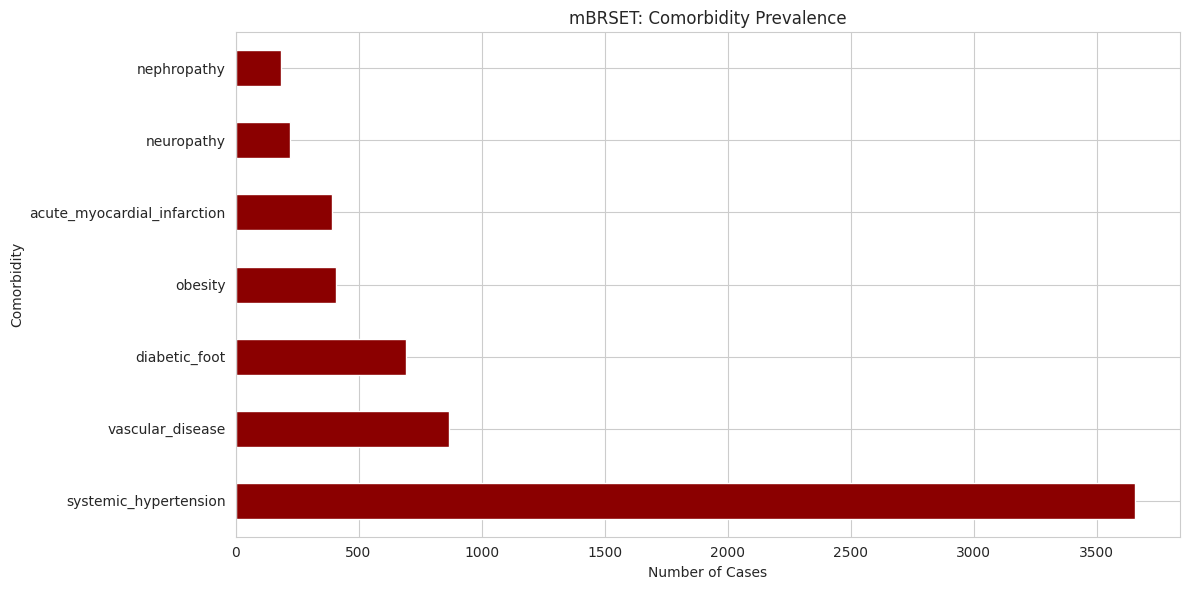


Comorbidity prevalence:
systemic_hypertension          3656.0
vascular_disease                868.0
diabetic_foot                   692.0
obesity                         408.0
acute_myocardial_infarction     392.0
neuropathy                      220.0
nephropathy                     184.0
dtype: float64


In [13]:
# Comorbidities analysis
comorbidity_cols = ['systemic_hypertension', 'obesity', 'vascular_disease', 
                    'acute_myocardial_infarction', 'nephropathy', 'neuropathy', 'diabetic_foot']

comorbidity_prevalence = mbrset_df[comorbidity_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
comorbidity_prevalence.plot(kind='barh', color='darkred')
plt.title('mBRSET: Comorbidity Prevalence')
plt.xlabel('Number of Cases')
plt.ylabel('Comorbidity')
plt.tight_layout()
plt.show()

print("\nComorbidity prevalence:")
print(comorbidity_prevalence)

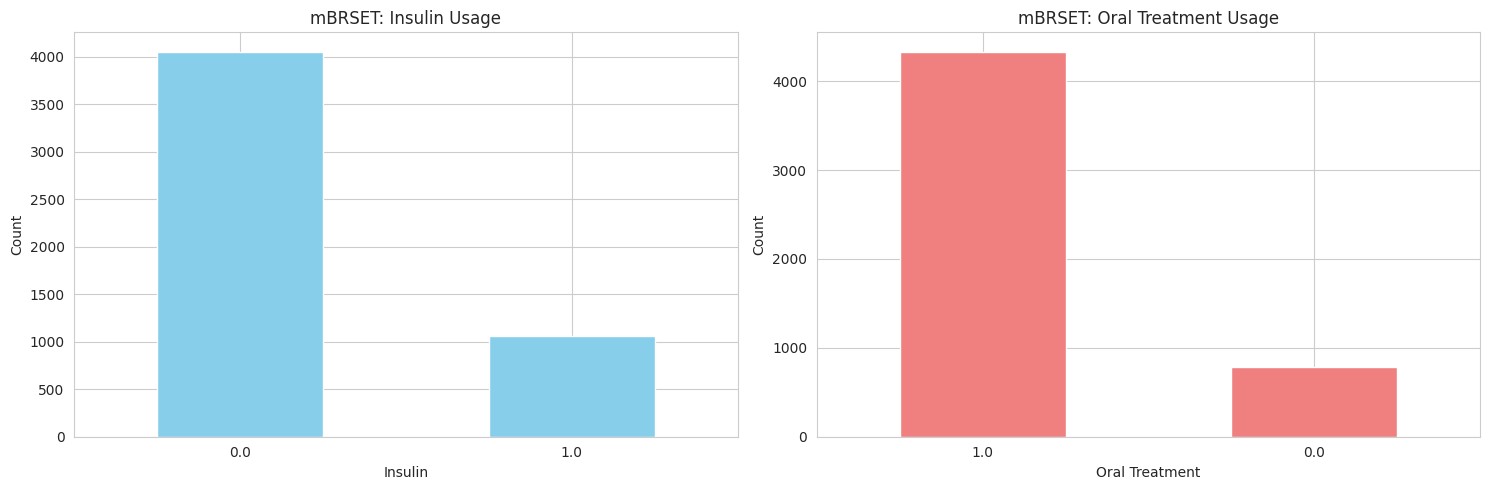

In [14]:
# Treatment patterns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Insulin usage
mbrset_df['insulin'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('mBRSET: Insulin Usage')
axes[0].set_xlabel('Insulin')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Oral treatment
mbrset_df['oraltreatment_dm'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('mBRSET: Oral Treatment Usage')
axes[1].set_xlabel('Oral Treatment')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 4. Sample Images Visualization

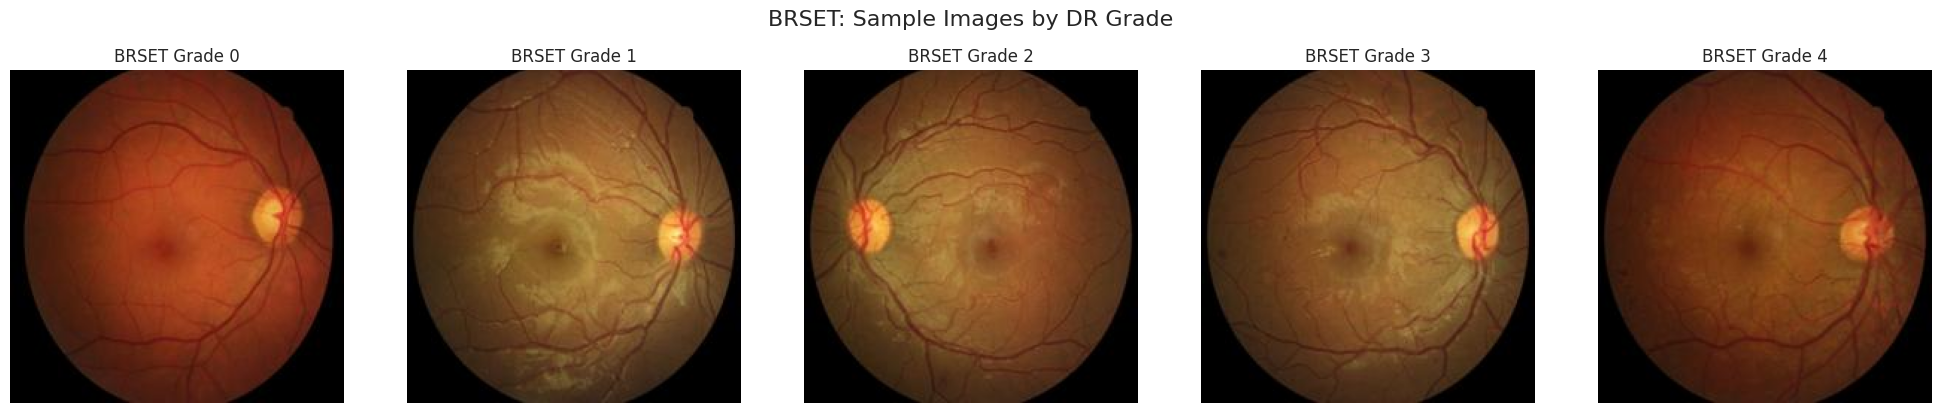

In [15]:
# Show sample images from BRSET with different DR grades
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
grades = [0, 1, 2, 3, 4]

for i, grade in enumerate(grades):
    sample = brset_df[brset_df['DR_ICDR'] == grade].iloc[0]
    img_path = brset_images_path / f"{sample['image_id']}.jpg"
    
    if img_path.exists():
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f'BRSET Grade {grade}')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'Image not found', ha='center', va='center')
        axes[i].axis('off')

plt.suptitle('BRSET: Sample Images by DR Grade', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

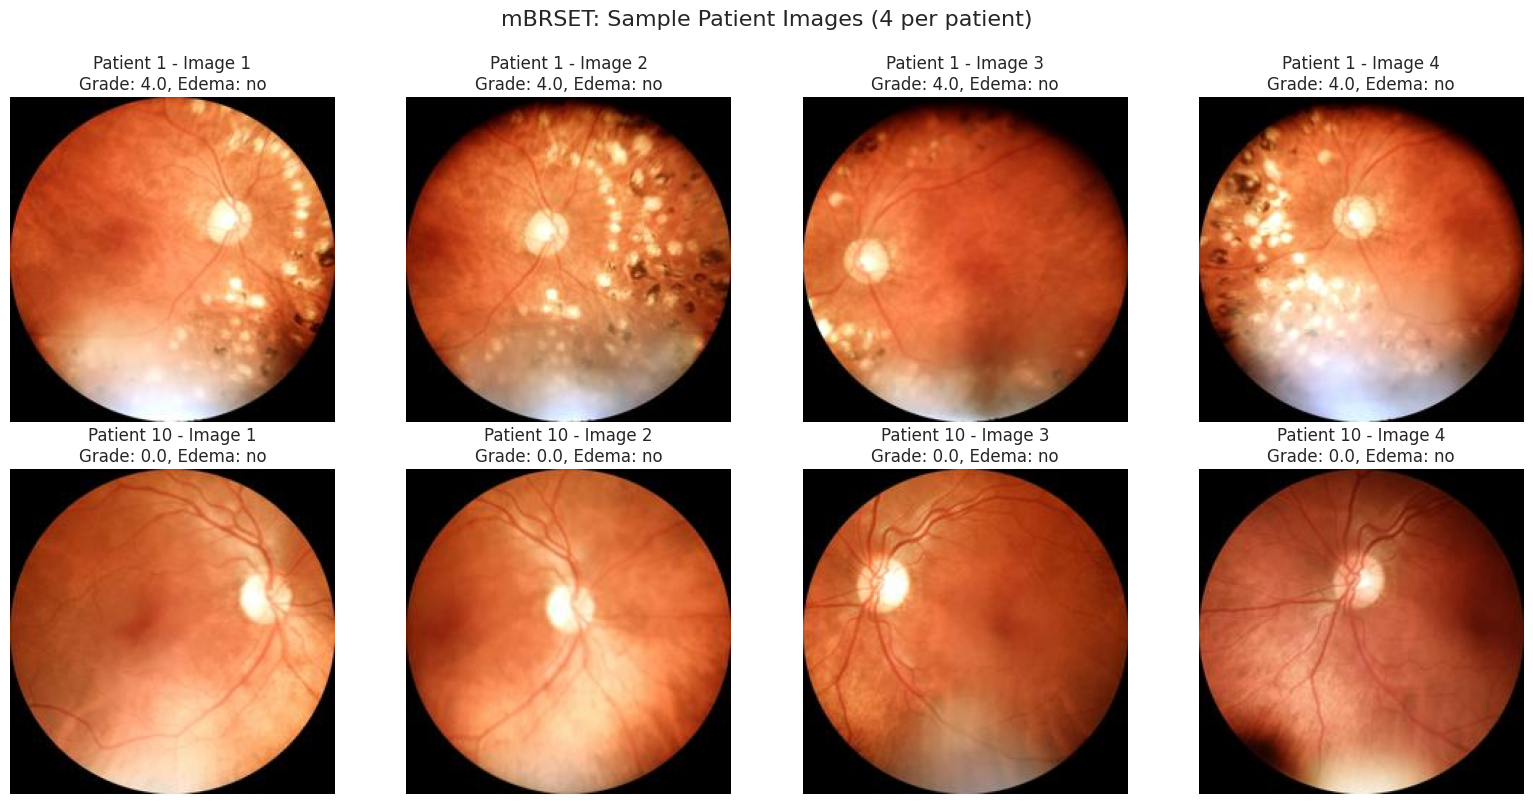

In [16]:
# Show sample images from mBRSET
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Select 2 patients with all 4 images
sample_patients = mbrset_df['patient'].unique()[:2]

for idx, patient in enumerate(sample_patients):
    patient_imgs = mbrset_df[mbrset_df['patient'] == patient].sort_values('file')
    
    for i, (_, row) in enumerate(patient_imgs.iterrows()):
        img_path = mbrset_images_path / row['file']
        ax = axes[idx*4 + i]
        
        if img_path.exists():
            img = Image.open(img_path)
            ax.imshow(img)
            ax.set_title(f"Patient {patient} - Image {i+1}\nGrade: {row['final_icdr']}, Edema: {row['final_edema']}")
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
            ax.axis('off')

plt.suptitle('mBRSET: Sample Patient Images (4 per patient)', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

In [17]:
brset_df.columns

Index(['image_id', 'patient_id', 'camera', 'patient_age', 'comorbidities',
       'diabetes_time_y', 'insuline', 'patient_sex', 'exam_eye', 'diabetes',
       'nationality', 'optic_disc', 'vessels', 'macula', 'DR_SDRG', 'DR_ICDR',
       'focus', 'iluminaton', 'image_field', 'artifacts',
       'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd',
       'vascular_occlusion', 'hypertensive_retinopathy', 'drusens',
       'hemorrhage', 'retinal_detachment', 'myopic_fundus',
       'increased_cup_disc', 'other', 'quality'],
      dtype='object')

In [18]:
mbrset_df.columns

Index(['patient', 'age', 'sex', 'dm_time', 'insulin', 'insulin_time',
       'oraltreatment_dm', 'systemic_hypertension', 'insurance',
       'educational_level', 'alcohol_consumption', 'smoking', 'obesity',
       'vascular_disease', 'acute_myocardial_infarction', 'nephropathy',
       'neuropathy', 'diabetic_foot', 'file', 'laterality', 'final_artifacts',
       'final_quality', 'final_icdr', 'final_edema'],
      dtype='object')

In [20]:
brset_df.increased_cup_disc.unique()

array([1, 0])